✅ Setup complete.
orders:      (646945, 8)
web_traffic: (3652, 7)
promotions:  (50, 10)
payments:    (646945, 4)
order_items: (714669, 7)
sales:       (3833, 3)
✅ Date casting and Period splitting completed.


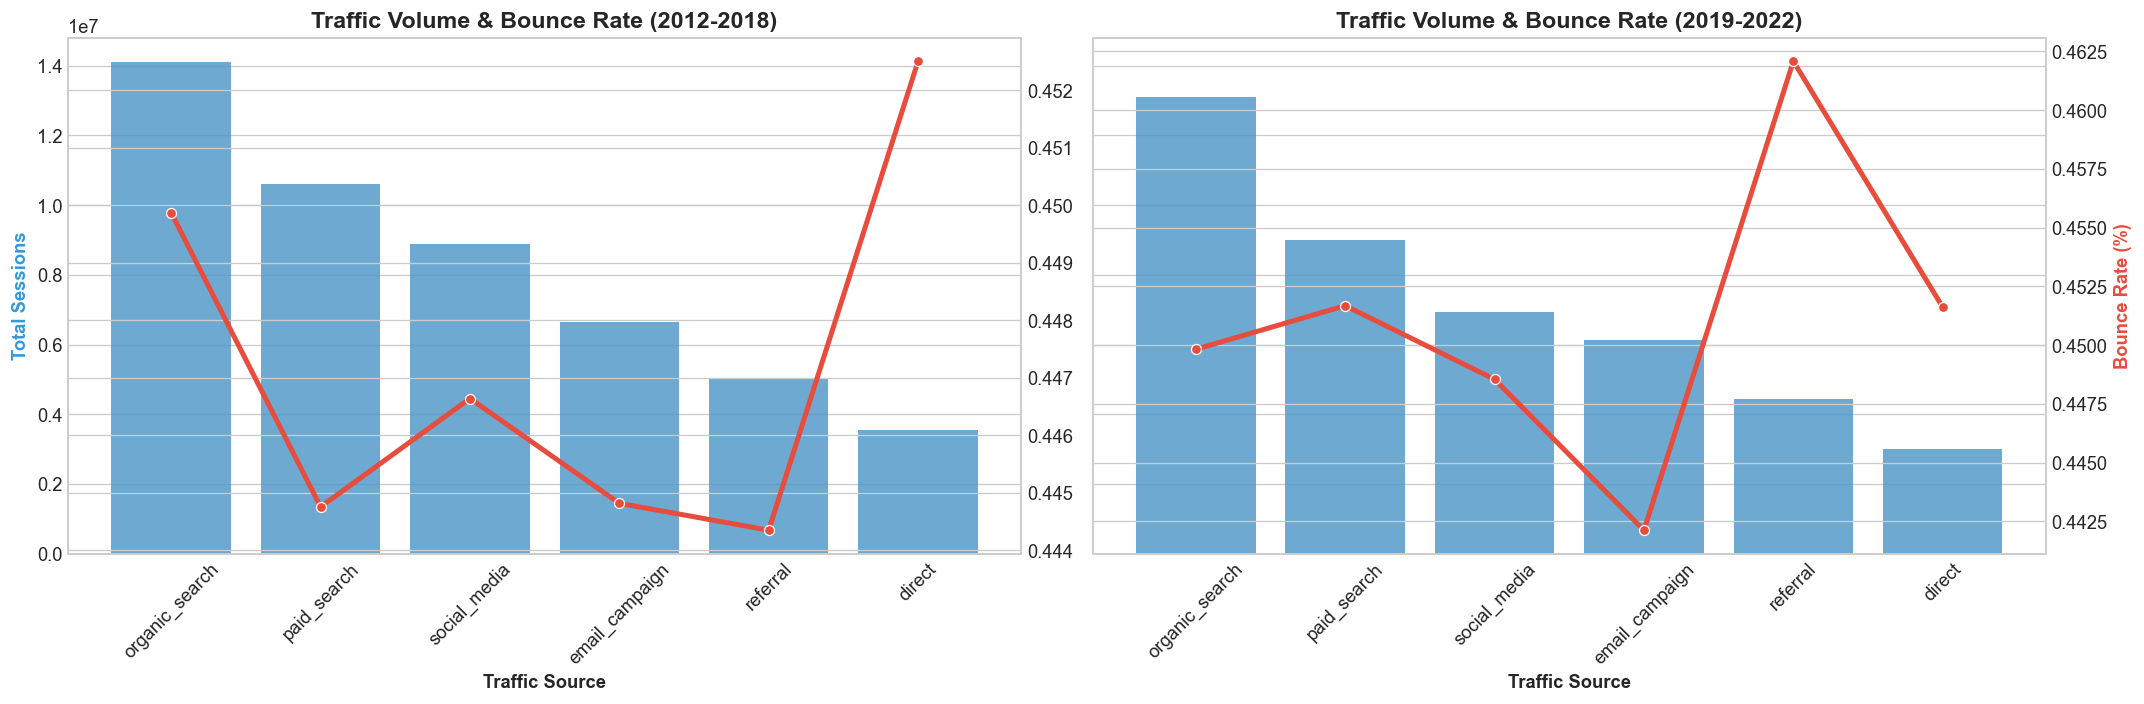

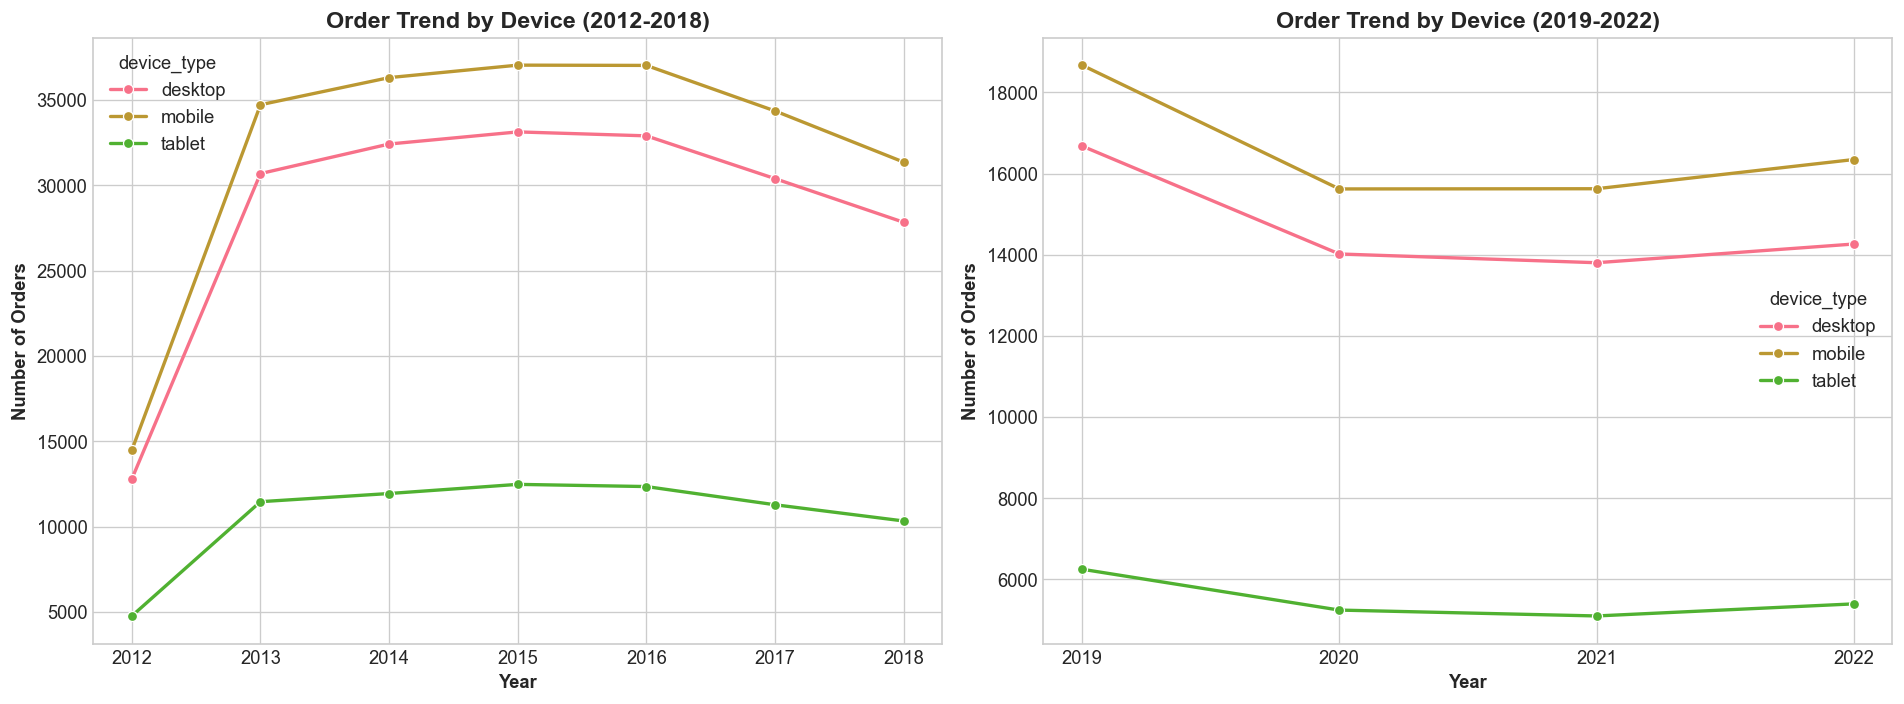

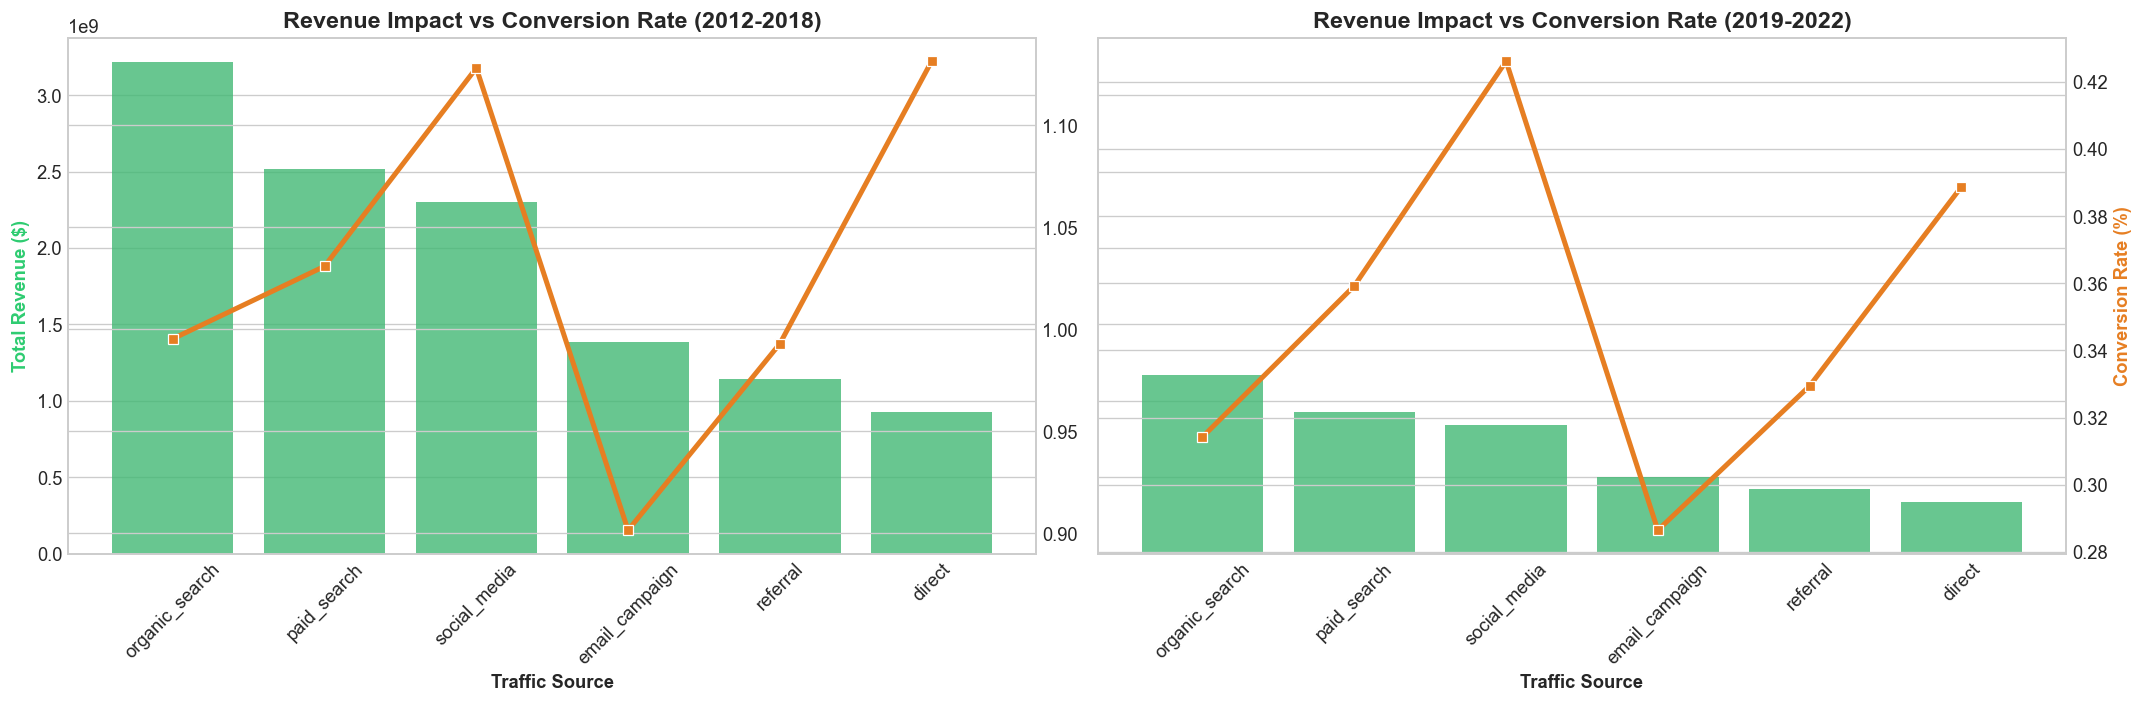

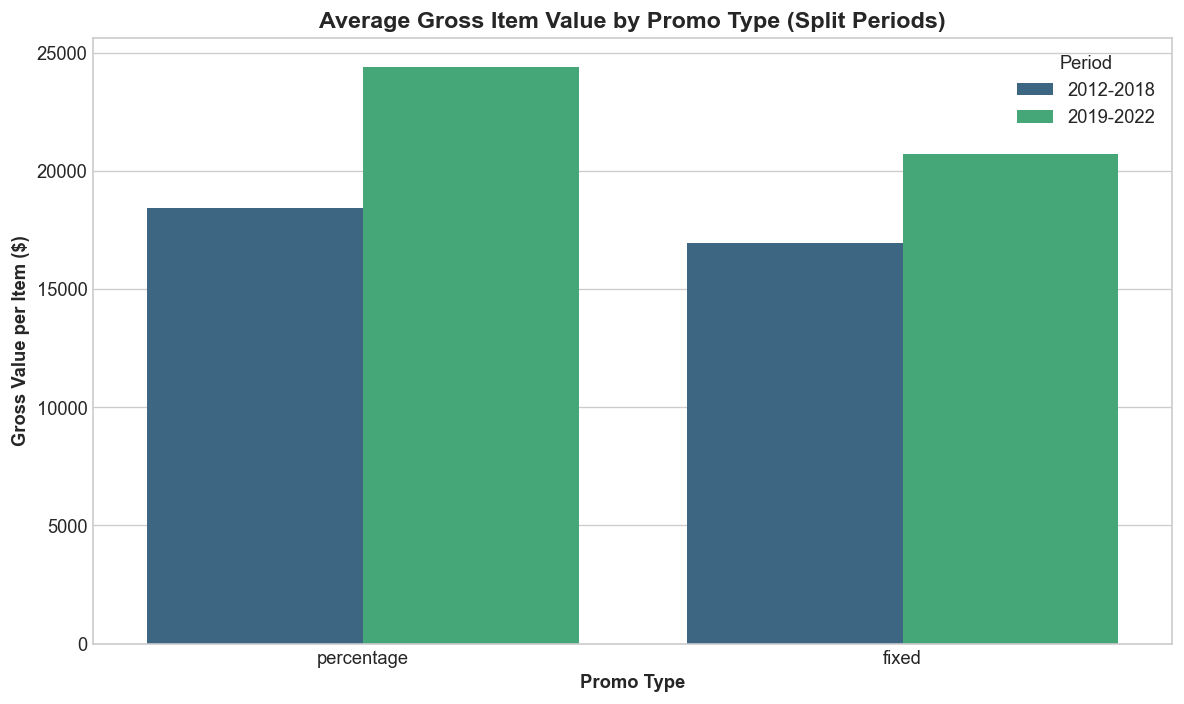


=== The Promotion Paradox (Average Daily Revenue by Period) ===
shape: (2, 4)
┌───────────┬──────────────────┬──────────────┬─────────────────┐
│ period    ┆ Before (14 days) ┆ During Promo ┆ After (14 days) │
│ ---       ┆ ---              ┆ ---          ┆ ---             │
│ str       ┆ f64              ┆ f64          ┆ f64             │
╞═══════════╪══════════════════╪══════════════╪═════════════════╡
│ 2012-2018 ┆ 4.9364e6         ┆ 4.9332e6     ┆ 5.2954e6        │
│ 2019-2022 ┆ 3.0322e6         ┆ 3.0795e6     ┆ 2.9692e6        │
└───────────┴──────────────────┴──────────────┴─────────────────┘


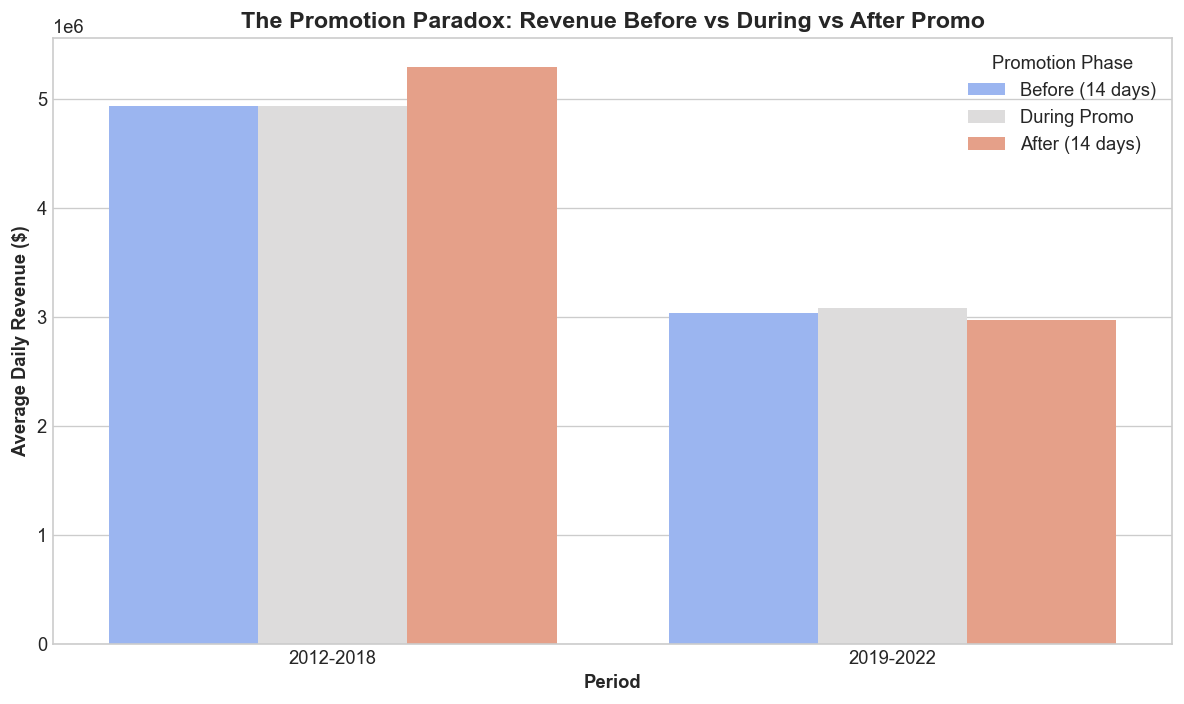


📝 SUMMARY — Day 5 Module 5 (Marketing) - SPLIT ANALYSIS

[2012-2018]:
- Channel with Best Conversion Rate: direct (1.13%)

[2019-2022]:
- Channel with Best Conversion Rate: social_media (0.43%)

📊 Split Figures saved to: /Users/khanhnq35/Documents/Datathon_Outliers/figures


In [1]:
"""
Day 5: EDA — Module 5 (Marketing & Digital Performance) - SPLIT PERIODS
Owner: Nguyễn Quốc Khánh (Tech Lead)
Mục tiêu: Phân tích so sánh 2 giai đoạn (2012-2018) và (2019-2022) cho Marketing Performance.
"""

# ============================================================
# CELL 1: Setup & Imports
# ============================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os
import warnings
from datetime import timedelta

# %matplotlib inline

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("..", "src")))

try:
    from data_loader import DataLoader
except ImportError:
    print("Warning: data_loader module not found, make sure src/data_loader.py exists.")

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 14})

FIGURES_DIR = os.path.abspath(os.path.join("..", "figures"))
os.makedirs(FIGURES_DIR, exist_ok=True)
print("✅ Setup complete.")

# ============================================================
# CELL 2: Load Data 
# ============================================================
loader = DataLoader()

orders = loader.load("orders")
web_traffic = loader.load("web_traffic")
promotions = loader.load("promotions")
payments = loader.load("payments")
order_items = loader.load("order_items")
sales = loader.load("sales")

print(f"orders:      {orders.shape}")
print(f"web_traffic: {web_traffic.shape}")
print(f"promotions:  {promotions.shape}")
print(f"payments:    {payments.shape}")
print(f"order_items: {order_items.shape}")
print(f"sales:       {sales.shape}")

# ============================================================
# CELL 3: Date Casting & Period Splitting
# ============================================================
# Web Traffic
if web_traffic["date"].dtype == pl.String:
    web_traffic = web_traffic.with_columns(
        pl.col("date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime).alias("session_date")
    )
else:
    web_traffic = web_traffic.with_columns(pl.col("date").cast(pl.Datetime).alias("session_date"))

web_traffic = web_traffic.with_columns(
    pl.when(pl.col("session_date").dt.year() <= 2018).then(pl.lit("2012-2018")).otherwise(pl.lit("2019-2022")).alias("period")
)

# Orders
if orders["order_date"].dtype == pl.String:
    orders = orders.with_columns(
        pl.col("order_date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime)
    )
else:
    orders = orders.with_columns(pl.col("order_date").cast(pl.Datetime))

orders = orders.with_columns(
    pl.when(pl.col("order_date").dt.year() <= 2018).then(pl.lit("2012-2018")).otherwise(pl.lit("2019-2022")).alias("period")
)

# Sales
if sales["Date"].dtype == pl.String:
    sales = sales.with_columns(pl.col("Date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime))
else:
    sales = sales.with_columns(pl.col("Date").cast(pl.Datetime))

sales = sales.with_columns(
    pl.when(pl.col("Date").dt.year() <= 2018).then(pl.lit("2012-2018")).otherwise(pl.lit("2019-2022")).alias("period")
)

# Promotions
for col in ["start_date", "end_date"]:
    if promotions[col].dtype == pl.String:
        promotions = promotions.with_columns(pl.col(col).str.strptime(pl.Date, "%Y-%m-%d", strict=False).cast(pl.Datetime))
    else:
        promotions = promotions.with_columns(pl.col(col).cast(pl.Datetime))

promotions = promotions.with_columns(
    pl.when(pl.col("start_date").dt.year() <= 2018).then(pl.lit("2012-2018")).otherwise(pl.lit("2019-2022")).alias("period")
)

print("✅ Date casting and Period splitting completed.")

# ============================================================
# CELL 4: 3.1 — Traffic Source & Bounce Rate Overview
# ============================================================
web_traffic = web_traffic.with_columns((pl.col("sessions") * pl.col("bounce_rate")).alias("bounces"))

traffic_stats = web_traffic.group_by(["period", "traffic_source"]).agg(
    pl.col("sessions").sum().alias("total_sessions"),
    pl.col("bounces").sum().alias("total_bounces")
).with_columns(
    (pl.col("total_bounces") / pl.col("total_sessions") * 100).alias("overall_bounce_rate_pct")
).sort(["period", "total_sessions"], descending=[False, True])

traffic_pd = traffic_stats.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for i, period in enumerate(["2012-2018", "2019-2022"]):
    df_period = traffic_pd[traffic_pd["period"] == period]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    sns.barplot(data=df_period, x="traffic_source", y="total_sessions", color="#3498db", alpha=0.8, ax=ax1)
    sns.lineplot(data=df_period, x="traffic_source", y="overall_bounce_rate_pct", color="#e74c3c", marker="o", linewidth=3, ax=ax2)
    
    ax1.set_title(f"Traffic Volume & Bounce Rate ({period})", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Traffic Source", fontweight="bold")
    ax1.set_ylabel("Total Sessions" if i == 0 else "", color="#3498db", fontweight="bold")
    ax2.set_ylabel("Bounce Rate (%)" if i == 1 else "", color="#e74c3c", fontweight="bold")
    ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_traffic_bounce_split.png"))
plt.show()

# ============================================================
# CELL 5: 3.2 — Device Trend Analysis in Orders
# ============================================================
orders = orders.with_columns(pl.col("order_date").dt.year().alias("order_year"))
device_trend = orders.group_by(["period", "order_year", "device_type"]).agg(
    pl.count().alias("total_orders")
).sort(["order_year", "device_type"])

device_pd = device_trend.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, period in enumerate(["2012-2018", "2019-2022"]):
    df_period = device_pd[device_pd["period"] == period]
    sns.lineplot(data=df_period, x="order_year", y="total_orders", hue="device_type", marker="o", linewidth=2, ax=axes[i])
    axes[i].set_title(f"Order Trend by Device ({period})", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Year", fontweight="bold")
    axes[i].set_ylabel("Number of Orders", fontweight="bold")
    axes[i].set_xticks(df_period["order_year"].unique())

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_device_trend_split.png"))
plt.show()

# ============================================================
# CELL 6: 4.1 — Channel Attribution & Conversion Rate
# ============================================================
order_revenue = payments.group_by("order_id").agg(
    pl.col("payment_value").sum().alias("order_revenue")
)
orders_with_revenue = orders.join(order_revenue, on="order_id", how="left")

order_source_stats = orders_with_revenue.group_by(["period", "order_source"]).agg(
    pl.count().alias("total_orders"),
    pl.col("order_revenue").sum().alias("total_revenue")
).rename({"order_source": "traffic_source"})

conversion_stats = traffic_stats.join(order_source_stats, on=["period", "traffic_source"], how="left")
conversion_stats = conversion_stats.with_columns(
    (pl.col("total_orders") / pl.col("total_sessions") * 100).alias("conversion_rate_pct"),
    (pl.col("total_sessions") / pl.col("total_orders")).alias("sessions_per_order"),
    (pl.col("total_revenue") / pl.col("total_orders")).alias("avg_order_value")
).sort(["period", "total_revenue"], descending=[False, True])

conv_pd = conversion_stats.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for i, period in enumerate(["2012-2018", "2019-2022"]):
    df_period = conv_pd[conv_pd["period"] == period]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    sns.barplot(data=df_period, x="traffic_source", y="total_revenue", color="#2ecc71", alpha=0.8, ax=ax1)
    sns.lineplot(data=df_period, x="traffic_source", y="conversion_rate_pct", color="#e67e22", marker="s", linewidth=3, ax=ax2)
    
    ax1.set_title(f"Revenue Impact vs Conversion Rate ({period})", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Traffic Source", fontweight="bold")
    ax1.set_ylabel("Total Revenue ($)" if i == 0 else "", color="#2ecc71", fontweight="bold")
    ax2.set_ylabel("Conversion Rate (%)" if i == 1 else "", color="#e67e22", fontweight="bold")
    ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_channel_attribution_split.png"))
plt.show()

# ============================================================
# CELL 7: 4.2 — Promo Performance Analysis
# ============================================================
items_with_promo = order_items.filter(pl.col("promo_id").is_not_null())
items_with_promo = items_with_promo.join(promotions, on="promo_id", how="left")

promo_stats = items_with_promo.group_by(["period", "promo_type"]).agg(
    pl.count().alias("times_applied"),
    pl.col("discount_amount").sum().alias("total_discount"),
    (pl.col("quantity") * pl.col("unit_price")).sum().alias("gross_revenue_from_promo")
).with_columns(
    (pl.col("gross_revenue_from_promo") / pl.col("times_applied")).alias("avg_gross_per_item")
).sort(["period", "gross_revenue_from_promo"], descending=[False, True])

promo_pd = promo_stats.to_pandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=promo_pd, x="promo_type", y="avg_gross_per_item", hue="period", palette="viridis")
plt.title("Average Gross Item Value by Promo Type (Split Periods)", fontsize=14, fontweight="bold")
plt.xlabel("Promo Type", fontweight="bold")
plt.ylabel("Gross Value per Item ($)", fontweight="bold")
plt.legend(title="Period")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_promo_aov_split.png"))
plt.show()

# ============================================================
# CELL 8: 4.3 — The Promotion Paradox (Forward Demand Analysis)
# ============================================================
promo_effects = []
for row in promotions.iter_rows(named=True):
    start = row["start_date"]
    end = row["end_date"]
    if start is None or end is None: continue
    
    before_start = start - timedelta(days=14)
    before_end = start - timedelta(days=1)
    
    after_start = end + timedelta(days=1)
    after_end = end + timedelta(days=14)
    
    rev_before = sales.filter((pl.col("Date") >= before_start) & (pl.col("Date") <= before_end))["Revenue"].mean()
    rev_during = sales.filter((pl.col("Date") >= start) & (pl.col("Date") <= end))["Revenue"].mean()
    rev_after = sales.filter((pl.col("Date") >= after_start) & (pl.col("Date") <= after_end))["Revenue"].mean()
    
    promo_effects.append({
        "promo_name": row["promo_name"],
        "period": row["period"],
        "Before (14 days)": rev_before,
        "During Promo": rev_during,
        "After (14 days)": rev_after
    })

effects_df = pl.DataFrame(promo_effects).drop_nulls()

# Tính trung bình theo từng period
avg_effects = effects_df.group_by("period").agg(
    pl.col("Before (14 days)").mean(), 
    pl.col("During Promo").mean(), 
    pl.col("After (14 days)").mean()
).sort("period")

print("\n=== The Promotion Paradox (Average Daily Revenue by Period) ===")
print(avg_effects)

avg_pd = avg_effects.to_pandas().melt(id_vars=["period"], var_name="Promo_Phase", value_name="Avg_Daily_Revenue")

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_pd, x="period", y="Avg_Daily_Revenue", hue="Promo_Phase", palette="coolwarm")
plt.title("The Promotion Paradox: Revenue Before vs During vs After Promo", fontsize=14, fontweight="bold")
plt.xlabel("Period", fontweight="bold")
plt.ylabel("Average Daily Revenue ($)", fontweight="bold")
plt.legend(title="Promotion Phase")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day5_promo_paradox_split.png"))
plt.show()

# ============================================================
# CELL 9: Summary Statistics & Final Narrative
# ============================================================
print("\n" + "=" * 60)
print("📝 SUMMARY — Day 5 Module 5 (Marketing) - SPLIT ANALYSIS")
print("=" * 60)

for period in ["2012-2018", "2019-2022"]:
    period_conv = conversion_stats.filter(pl.col("period") == period).sort("conversion_rate_pct", descending=True)
    best_conv_channel = period_conv["traffic_source"][0]
    best_conv_rate = period_conv["conversion_rate_pct"][0]
    
    print(f"\n[{period}]:")
    print(f"- Channel with Best Conversion Rate: {best_conv_channel} ({best_conv_rate:.2f}%)")

print("\n" + "=" * 60)
print("📊 Split Figures saved to:", FIGURES_DIR)
print("=" * 60)
